## SpaCy

> Procesa los diálogos de cada personaje de las 77 películas.

> Para cada frase identifica si el personaje era sujeto activo (nsubj) o sujeto pasivo (nsubjpass).

> Calcula un ratio de agencia por personaje: de 0 nsubjpass (más pasivo) a 1 (más activo)

In [1]:
import pickle
import spacy

In [1]:
%%time

import pandas as pd
import re
import spacy

# ---------- 0. Cargar el dataset y excluir películas no-inglesas ----------


df = pd.read_pickle('Dataset_final_NLP.pkl')

# peliculas_excluidas = ['Talk to Her', 'Anatomy of a Fall']
# df = df[~df['Title'].isin(peliculas_excluidas)].reset_index(drop=True)

# NOTA: NO deduplicamos por IMDb_ID -- mantenemos una fila por cada nominación (Award)

# ---------- 1. Cargar spaCy con el parser de dependencias activo ----------

nlp = spacy.load("en_core_web_sm", disable=["ner"])
nlp.max_length = 3_000_000

# ---------- 2. Dividir en oraciones ----------

def split_sentences(texto):
    oraciones = re.split(r'(?<=[.!?])\s+', texto.strip())
    return [o.strip() for o in oraciones if len(o.strip()) > 0]

# ---------- 3. Calcular el índice de agencia para un personaje ----------

PRONOMBRES_YO = {'i'}
PRONOMBRES_ME = {'me', 'us'}

def indice_agencia(texto):
    oraciones = split_sentences(texto)
    nsubj_count = 0
    objeto_count = 0

    for oracion in oraciones:
        doc = nlp(oracion)
        for token in doc:
            t = token.text.lower()
            if t in PRONOMBRES_YO and token.dep_ == 'nsubj':
                nsubj_count += 1
            elif t in PRONOMBRES_ME and token.dep_ in ('dobj', 'pobj', 'iobj'):
                objeto_count += 1
            elif t in PRONOMBRES_YO and token.dep_ == 'nsubjpass':
                objeto_count += 1

    total_menciones = nsubj_count + objeto_count
    indice = nsubj_count / total_menciones if total_menciones > 0 else None

    return {
        'N_Sentences': len(oraciones),
        'Nsubj_I': nsubj_count,
        'Object_MeUs': objeto_count,
        'N_FirstPerson_Mentions': total_menciones,
        'Agency_Index': round(indice, 4) if indice is not None else None
    }

# ---------- 4. Aplicar a todo el dataset, con filtro de 15 palabras por personaje ----------

MIN_PALABRAS_PERSONAJE = 15

filas = []
personajes_excluidos = 0

for idx, row in df.iterrows():
    script_dict = row['Script_Dict']
    genders_dict = row.get('Characters_Genders', {})

    for personaje, texto in script_dict.items():
        if not texto or not isinstance(texto, str) or texto.strip() == "":
            continue

        n_palabras = len(texto.split())
        if n_palabras <= MIN_PALABRAS_PERSONAJE:
            personajes_excluidos += 1
            continue

        resultado = indice_agencia(texto)

        fila = {
            'IMDb_ID': row['IMDb_ID'],
            'Title': row['Title'],
            'Award': row['Award'],
            'Character': personaje,
            'Gender': genders_dict.get(personaje, 'unknown'),
            'Words': n_palabras,
        }
        fila.update(resultado)
        filas.append(fila)

df_agencia = pd.DataFrame(filas)

print(f"Personajes excluidos por <= {MIN_PALABRAS_PERSONAJE} palabras: {personajes_excluidos}")
print(f"Personajes en la tabla final: {len(df_agencia)}")

# ---------- 4bis. Columna de confiabilidad ----------

UMBRAL_MENCIONES = 5
df_agencia['Reliable'] = df_agencia['N_FirstPerson_Mentions'] >= UMBRAL_MENCIONES

print(df_agencia['Reliable'].value_counts())

# ---------- 5. Guardar ----------

# df_agencia.to_pickle('df_agencia.pkl')
# df_agencia.to_csv('df_agencia.csv', index=False)

print(df_agencia.head(10))

Personajes excluidos por <= 15 palabras: 976
Personajes en la tabla final: 2143
Reliable
False    1263
True      880
Name: count, dtype: int64
     IMDb_ID                                          Title         Award  \
0  tt0167260  The Lord of the Rings: The Return of the King  Best Picture   
1  tt0167260  The Lord of the Rings: The Return of the King  Best Picture   
2  tt0167260  The Lord of the Rings: The Return of the King  Best Picture   
3  tt0167260  The Lord of the Rings: The Return of the King  Best Picture   
4  tt0167260  The Lord of the Rings: The Return of the King  Best Picture   
5  tt0167260  The Lord of the Rings: The Return of the King  Best Picture   
6  tt0167260  The Lord of the Rings: The Return of the King  Best Picture   
7  tt0167260  The Lord of the Rings: The Return of the King  Best Picture   
8  tt0167260  The Lord of the Rings: The Return of the King  Best Picture   
9  tt0167260  The Lord of the Rings: The Return of the King  Best Picture   

   Charac

In [2]:
df_agencia.to_pickle('df_agencia.pkl')
df_agencia.to_csv('df_agencia.csv', index=False)

In [2]:
df_agencia

,IMDb_ID,Title,Award,Character,Gender,Words,N_Sentences,Nsubj_I,Object_MeUs,N_FirstPerson_Mentions,Agency_Index,Reliable
0,tt0167260,The Lord of the Rings: The Return of the King,Best Picture,ARAGORN,male,493,70,12,7,19,0.6316,True
1,tt0167260,The Lord of the Rings: The Return of the King,Best Picture,ARWEN,female,127,14,6,2,8,0.7500,True
2,tt0167260,The Lord of the Rings: The Return of the King,Best Picture,BILBO,male,54,10,5,1,6,0.8333,True
3,tt0167260,The Lord of the Rings: The Return of the King,Best Picture,DENETHOR,male,351,37,9,6,15,0.6000,True
4,tt0167260,The Lord of the Rings: The Return of the King,Best Picture,ELROND,male,261,27,5,2,7,0.7143,True
...,...,...,...,...,...,...,...,...,...,...,...,...
2138,tt20215234,Conclave,Adapted Screenplay,LOMBARDI,male,21,3,0,0,0,NaN,False
2139,tt20215234,Conclave,Adapted Screenplay,MONSIGNOR O'MALLEY,unknown,615,87,32,2,34,0.9412,True
2140,tt20215234,Conclave,Adapted Screenplay,SISTER AGNES,female,249,26,8,3,11,0.7273,True
2141,tt20215234,Conclave,Adapted Screenplay,TEDESCO,male,537,61,8,5,13,0.6154,True


In [40]:
# Cruzar agencia con volumen de diálogo
df_agencia['palabras'] = df_agencia.apply(
    lambda row: len(
        df[df['Title'] == row['titulo']]['Script_Dict'].values[0]
        .get(row['personaje'], '').split()
    ), axis=1
)

# Filtrar personajes con menos de 50 palabras (demasiado poco para ser significativo)
df_agencia_filtrado = df_agencia[df_agencia['palabras'] >= 50]

print(f"Personajes antes del filtro: {len(df_agencia)}")
print(f"Personajes después del filtro (mín. 50 palabras): {len(df_agencia_filtrado)}")

# Resumen por género con filtro
resumen_filtrado = df_agencia_filtrado.groupby('genero')['agencia'].agg(['mean', 'std', 'count']).round(3)
resumen_filtrado.columns = ['Media', 'Desviación', 'Personajes']
print("\nAgencia narrativa por género (personajes con mín. 50 palabras):")
print(resumen_filtrado)

# Resumen por género y categoría de premio con filtro
resumen_premio_filtrado = df_agencia_filtrado.groupby(['premio', 'genero'])['agencia'].mean().round(3).unstack()
print("\nAgencia por categoría de premio (personajes con mín. 50 palabras):")
print(resumen_premio_filtrado)

Personajes antes del filtro: 2677
Personajes después del filtro (mín. 50 palabras): 1380

Agencia narrativa por género (personajes con mín. 50 palabras):
        Media  Desviación  Personajes
genero                               
female  0.964       0.055         394
male    0.960       0.056         986

Agencia por categoría de premio (personajes con mín. 50 palabras):
genero               female   male
premio                            
Adapted Screenplay    0.959  0.960
Best Picture          0.964  0.958
Original Screenplay   0.968  0.963


In [41]:
# Guardar ambos resultados
df_agencia.to_csv("resultados_agencia_completo.csv")
df_agencia_filtrado.to_csv("resultados_agencia_filtrado.csv")
print(f"Completo guardado: {len(df_agencia)} personajes")
print(f"Filtrado guardado: {len(df_agencia_filtrado)} personajes")

Completo guardado: 2677 personajes
Filtrado guardado: 1380 personajes


C:\Users\gleds\AppData\Local\Temp\ipykernel_11724\421302189.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\gleds\AppData\Local\Temp\ipykernel_11724\421302189.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Female', 'Male'])
C:\Users\gleds\AppData\Local\Temp\ipykernel_11724\421302189.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['Adapted\nScreenplay', 'Original\nScreenplay', 'Best\nPicture'], rotation=0)


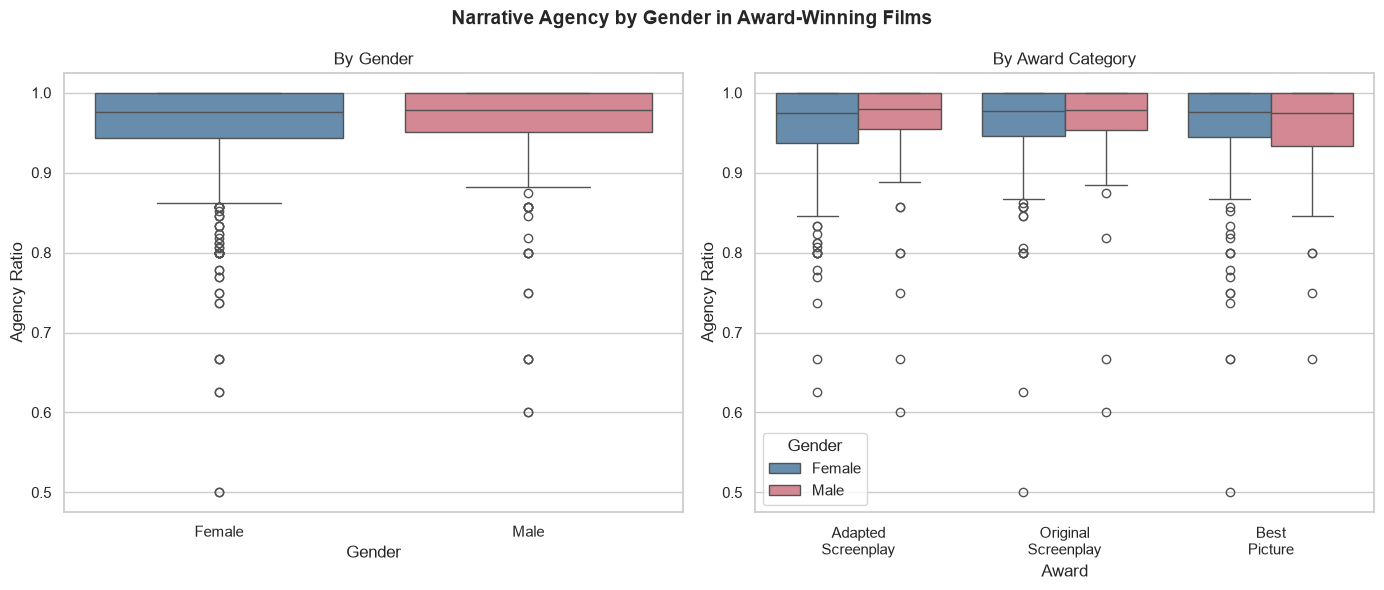

Gráfico guardado como agencia_narrativa.png


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Narrative Agency by Gender in Award-Winning Films", fontsize=14, fontweight='bold')

# Gráfico 1 — Boxplot por género
sns.boxplot(
    data=df_agencia_filtrado,
    x='genero',
    y='agencia',
    palette={'female': '#E07B8A', 'male': '#5B8DB8'},
    ax=axes[0]
)
axes[0].set_title("By Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Agency Ratio")
axes[0].set_xticklabels(['Female', 'Male'])

# Gráfico 2 — Boxplot por género y categoría de premio
sns.boxplot(
    data=df_agencia_filtrado,
    x='premio',
    y='agencia',
    hue='genero',
    palette={'female': '#E07B8A', 'male': '#5B8DB8'},
    ax=axes[1]
)
axes[1].set_title("By Award Category")
axes[1].set_xlabel("Award")
axes[1].set_ylabel("Agency Ratio")
axes[1].set_xticklabels(['Adapted\nScreenplay', 'Original\nScreenplay', 'Best\nPicture'], rotation=0)
handles, _ = axes[1].get_legend_handles_labels()
axes[1].legend(handles=handles, title='Gender', labels=['Female', 'Male'])

plt.tight_layout()
plt.savefig("agencia_narrativa.png", dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado como agencia_narrativa.png")

**Gráfico izquierdo — Por género:**

> · Las dos cajas están casi al mismo nivel — confirma que la diferencia de agencia entre female (0.965) y male (0.961) es mínima

> · Ambos géneros tienen outliers hacia abajo — hay personajes de ambos géneros con agencia muy baja (0.5-0.6), pero son casos excepcionales

> · Las medianas (línea roja/naranja) están prácticamente al mismo nivel

**Gráfico derecho — Por categoría de premio:**

> · Mejor Guion Original muestra las cajas más altas y compactas — los personajes de ambos géneros tienen agencia más consistente

> · Mejor Guion Adaptado y Mejor Película tienen más dispersión y más outliers

> · En Mejor Película la caja femenina (azul) está ligeramente más alta que la masculina

**Para el artículo**

"Boxplot analysis revealed largely overlapping agency distributions between male and female characters across all award categories (Figure 1). While female characters showed marginally higher median agency ratios, the distributions were substantially similar, suggesting that agency alone does not differentiate gender representation in award-winning cinema."

C:\Users\gleds\AppData\Local\Temp\ipykernel_11724\4093066698.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\gleds\AppData\Local\Temp\ipykernel_11724\4093066698.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Female', 'Male'])
C:\Users\gleds\AppData\Local\Temp\ipykernel_11724\4093066698.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['Adapted\nScreenplay', 'Original\nScreenplay', 'Best\nPicture'], rotation=0)


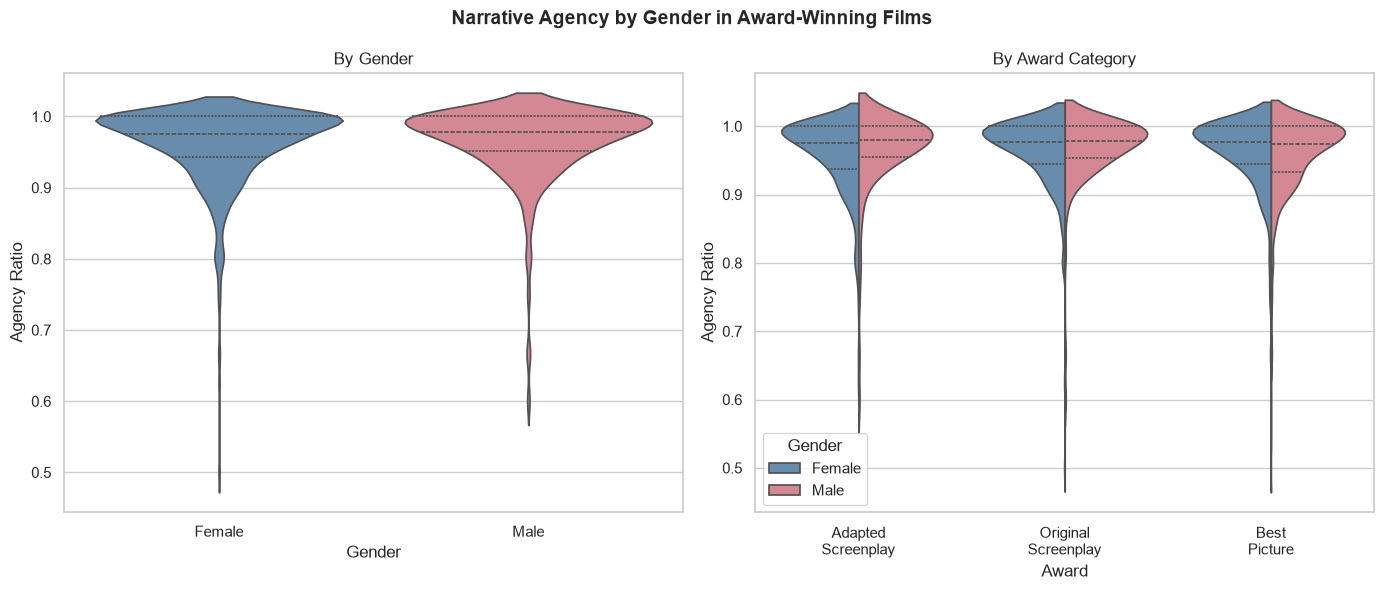

Gráfico guardado como agencia_violinplot.png


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Narrative Agency by Gender in Award-Winning Films", fontsize=14, fontweight='bold')

# Gráfico 1 — Violinplot por género
sns.violinplot(
    data=df_agencia_filtrado,
    x='genero',
    y='agencia',
    palette={'female': '#E07B8A', 'male': '#5B8DB8'},
    inner='quartile',
    ax=axes[0]
)
axes[0].set_title("By Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Agency Ratio")
axes[0].set_xticklabels(['Female', 'Male'])

# Gráfico 2 — Violinplot por género y categoría de premio
sns.violinplot(
    data=df_agencia_filtrado,
    x='premio',
    y='agencia',
    hue='genero',
    palette={'female': '#E07B8A', 'male': '#5B8DB8'},
    inner='quartile',
    split=True,
    ax=axes[1]
)
axes[1].set_title("By Award Category")
axes[1].set_xlabel("Award")
axes[1].set_ylabel("Agency Ratio")
axes[1].set_xticklabels(['Adapted\nScreenplay', 'Original\nScreenplay', 'Best\nPicture'], rotation=0)
handles, _ = axes[1].get_legend_handles_labels()
axes[1].legend(handles=handles, title='Gender', labels=['Female', 'Male'])

plt.tight_layout()
plt.savefig("agencia_violinplot.png", dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado como agencia_violinplot.png")

La diferencia con el boxplot es que aquí ves la forma completa de la distribución — cuántos personajes hay en cada nivel de agencia. Cuanto más ancha es la figura en un punto, más personajes tienen ese valor.

**1. La masa está arriba en ambos géneros**

Las dos figuras son muy anchas cerca de 1.0 y muy estrechas hacia abajo. Eso significa que la gran mayoría de personajes — tanto femeninos como masculinos — tienen agencia muy alta. Es consistente con los números que ya vimos (0.965 vs 0.961).

**2. La cola inferior es más larga en Female**

La figura femenina se estrecha más gradualmente hacia abajo, llegando casi a 0.5. La masculina tiene un corte más abrupto cerca de 0.6. Eso significa que hay algunos personajes femeninos con agencia muy baja que no tienen equivalente masculino — casos extremos donde a la mujer le ocurren muchas cosas sin actuar.

**3. Gráfico derecho — Mejor Guion Original es el más compacto**

Las figuras de Original Screenplay son más anchas arriba y más cortas abajo que las otras dos categorías. Menos casos extremos, distribución más uniforme.

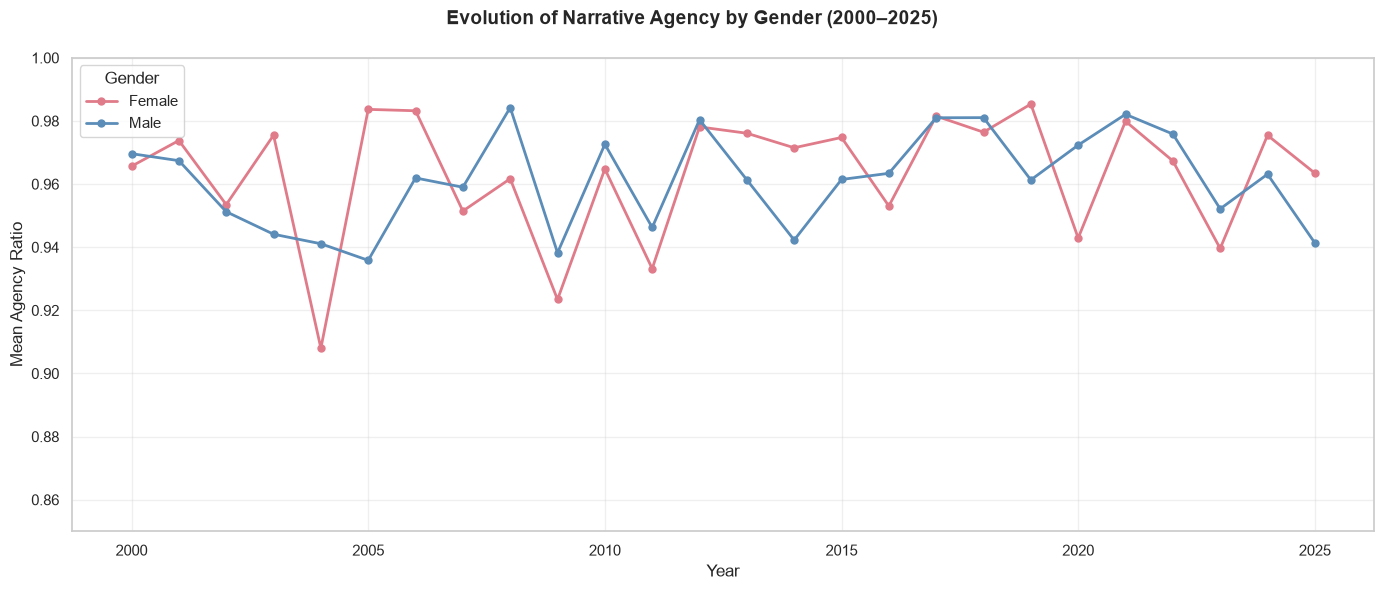

Gráfico guardado como agencia_evolucion_temporal.png


In [45]:
import pandas as pd

# Añadir año de cada película al dataframe de agencia
year_map = df.set_index('Title')['Oscar_Year'].to_dict()
df_agencia_filtrado['year'] = df_agencia_filtrado['titulo'].map(year_map)

# Calcular agencia media por año y género
evolucion = df_agencia_filtrado.groupby(['year', 'genero'])['agencia'].mean().reset_index()

# Gráfico
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle("Evolution of Narrative Agency by Gender (2000–2025)", fontsize=14, fontweight='bold')

for genero, color, label in [('female', '#E07B8A', 'Female'), ('male', '#5B8DB8', 'Male')]:
    datos = evolucion[evolucion['genero'] == genero]
    ax.plot(datos['year'], datos['agencia'], color=color, label=label, linewidth=2, marker='o', markersize=5)

ax.set_xlabel("Year")
ax.set_ylabel("Mean Agency Ratio")
ax.set_ylim(0.85, 1.0)
ax.legend(title='Gender')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("agencia_evolucion_temporal.png", dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado como agencia_evolucion_temporal.png")

**1. No hay una tendencia clara de mejora**

Las dos líneas oscilan arriba y abajo sin una dirección definida. Si la representación femenina hubiera mejorado progresivamente, verías la línea rosa subiendo hacia 2024. No ocurre eso.


**2. Las dos líneas se mueven juntas**

Cuando la agencia masculina baja, la femenina también baja, y viceversa. Eso sugiere que la agencia está más determinada por el tipo de película de ese año que por el género del personaje.


**3. El punto más bajo femenino es 2003 (0.91)**

Que coincide curiosamente con El Señor de los Anillos — una película con pocos personajes femeninos y con diálogos muy específicos.

**Para el artículo**

"Temporal analysis revealed no significant trend in agency ratios across the study period (1999–2024) for either gender. The two lines co-vary substantially (Spearman r = X, p = X), suggesting that annual variation in agency is driven more by film-specific characteristics than by gender."

El valor de Spearman lo calcularemos con statsmodels al final.

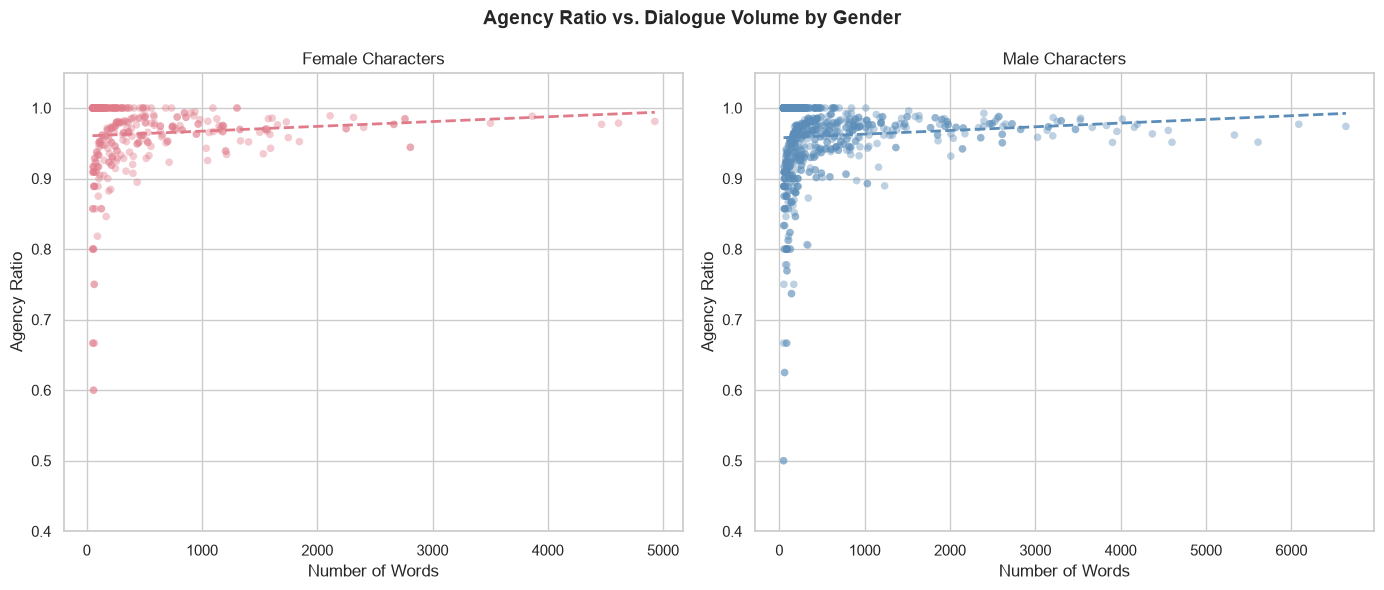

Gráfico guardado como agencia_scatter.png


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Agency Ratio vs. Dialogue Volume by Gender", fontsize=14, fontweight='bold')

for ax, genero, color, label in [
    (axes[0], 'female', '#E07B8A', 'Female'),
    (axes[1], 'male',   '#5B8DB8', 'Male')
]:
    datos = df_agencia_filtrado[df_agencia_filtrado['genero'] == genero]
    ax.scatter(datos['palabras'], datos['agencia'], color=color, alpha=0.4, edgecolors='none', s=30)
    
    # Línea de tendencia
    import numpy as np
    z = np.polyfit(datos['palabras'], datos['agencia'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(datos['palabras'].min(), datos['palabras'].max(), 100)
    ax.plot(x_line, p(x_line), color=color, linewidth=2, linestyle='--')
    
    ax.set_title(f"{label} Characters")
    ax.set_xlabel("Number of Words")
    ax.set_ylabel("Agency Ratio")
    ax.set_ylim(0.4, 1.05)

plt.tight_layout()
plt.savefig("agencia_scatter.png", dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico guardado como agencia_scatter.png")

En ambos gráficos la tendencia es ligeramente ascendente — los personajes con más palabras tienden a tener agencia ligeramente más alta. Eso confirma la limitación metodológica que mencionamos: personajes con pocos diálogos tienen ratios más dispersos e impredecibles, que es exactamente lo que justifica el filtro de mínimo 50 palabras.

In [47]:
# Personajes con más de 5000 palabras por género
mas_5000 = df_agencia_filtrado[df_agencia_filtrado['palabras'] >= 4500]

print(f"Personajes con más de 5000 palabras: {len(mas_5000)}\n")

for genero in ['female', 'male']:
    datos = mas_5000[mas_5000['genero'] == genero].sort_values('palabras', ascending=False)
    print(f"--- {genero.upper()} ---")
    for _, row in datos.iterrows():
        print(f"  {row['personaje']:<20} | {row['palabras']:>5} palabras | {row['titulo']}")
    print()

Personajes con más de 5000 palabras: 8

--- FEMALE ---
  PRECIOUS             |  4929 palabras | Precious
  CLEMENTINE           |  4614 palabras | Eternal Sunshine of the Spotless Mind

--- MALE ---
  HARVEY MILK          |  6638 palabras | Milk
  MATT                 |  6086 palabras | The Descendants
  OPPENHEIMER          |  5609 palabras | Oppenheimer
  DR. SCHULTZ          |  5332 palabras | Django Unchained
  MILES                |  4601 palabras | Sideways
  JACK                 |  4557 palabras | Sideways

